In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All"
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/summer-analytics-mid-hackathon/hacktest.csv
/kaggle/input/summer-analytics-mid-hackathon/hacktrain.csv


In [2]:
df = pd.read_csv("/kaggle/input/summer-analytics-mid-hackathon/hacktrain.csv")

In [3]:
df.isnull().sum()

Unnamed: 0       0
ID               0
class            0
20150720_N     560
20150602_N    1200
20150517_N     800
20150501_N     960
20150415_N     480
20150330_N    1120
20150314_N     720
20150226_N    1360
20150210_N     640
20150125_N    1040
20150109_N     880
20141117_N    1280
20141101_N     400
20141016_N    1440
20140930_N     800
20140813_N     560
20140626_N    1600
20140610_N     480
20140525_N     720
20140509_N     880
20140423_N    1760
20140407_N     640
20140322_N    1120
20140218_N    1440
20140202_N     560
20140117_N    1200
20140101_N     400
dtype: int64

In [4]:
df.fillna(df.mean(numeric_only=True), inplace=True) #simple mean imputation [This part has a lot of scope for imporovement.]
#keep in mind that the data is inherently noisy and the test dataset is not.
df.isnull().sum()

Unnamed: 0    0
ID            0
class         0
20150720_N    0
20150602_N    0
20150517_N    0
20150501_N    0
20150415_N    0
20150330_N    0
20150314_N    0
20150226_N    0
20150210_N    0
20150125_N    0
20150109_N    0
20141117_N    0
20141101_N    0
20141016_N    0
20140930_N    0
20140813_N    0
20140626_N    0
20140610_N    0
20140525_N    0
20140509_N    0
20140423_N    0
20140407_N    0
20140322_N    0
20140218_N    0
20140202_N    0
20140117_N    0
20140101_N    0
dtype: int64

In [5]:
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import classification_report

# Drop ID column
df.drop(columns=['ID'], inplace=True)

# Encode class column
label_encoder = LabelEncoder()
df['class'] = label_encoder.fit_transform(df['class'])

# Split into features and target
X = df.drop(columns=['class'])
y = df['class']

# Feature scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y)

# Fit logistic regression with higher iterations
model = LogisticRegression(
    multi_class='multinomial',
    solver='lbfgs',
    max_iter=1000,  # increased from 10
    random_state=42
)
model.fit(X_train, y_train)

# Predict and evaluate
y_pred = model.predict(X_test)

print(classification_report(
    y_test,
    y_pred,
    labels=list(range(len(label_encoder.classes_))),
    target_names=label_encoder.classes_,
    zero_division=0  # Avoid undefined metric warnings
))

              precision    recall  f1-score   support

        farm       0.85      0.88      0.86       168
      forest       1.00      0.99      0.99      1232
       grass       0.83      0.64      0.72        39
  impervious       0.82      0.89      0.85       134
     orchard       1.00      0.50      0.67         6
       water       0.89      0.81      0.85        21

    accuracy                           0.96      1600
   macro avg       0.90      0.78      0.83      1600
weighted avg       0.96      0.96      0.96      1600



In [6]:
test_data = pd.read_csv("/kaggle/input/summer-analytics-mid-hackathon/hacktest.csv")
test_data.shape

(2845, 29)

In [7]:
ID=test_data['ID']
test_data.drop(['ID'],axis=1,inplace=True)

In [8]:
test_data_scaled = scaler.transform(test_data)
y_test = model.predict(test_data_scaled)

In [9]:
y_test

array([1, 1, 1, ..., 5, 5, 5])

In [10]:
y_decoded = label_encoder.inverse_transform(y_test)
y_decoded

array(['forest', 'forest', 'forest', ..., 'water', 'water', 'water'],
      dtype=object)

In [11]:
result = pd.DataFrame({
    'ID': ID,
    'class': y_decoded
})

In [12]:
result

,ID,class
0,1,forest
1,2,forest
2,3,forest
3,4,forest
4,5,forest
...,...,...
2840,2841,water
2841,2842,water
2842,2843,water
2843,2844,water


In [13]:
# result.to_csv("submission.csv", index=False) 
# this file will appear under the output section of the right navbar. You need to submit this csv file

In [14]:
# result.to_csv("submission.csv", index=False)

# My Code

In [15]:
# WARNING: This command will permanently delete all files and folders
# inside /kaggle/working/.

# First, list the files to see what will be deleted
print("--- Before Deletion ---")
!ls -l /kaggle/working/

# Now, delete everything inside the directory
!rm -rf /kaggle/working/*

# Verify that the directory is empty
print("\n--- After Deletion ---")
!ls -l /kaggle/working/

--- Before Deletion ---
total 0

--- After Deletion ---
total 0


In [16]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import GridSearchCV
from xgboost import XGBClassifier

In [17]:
print("Loading data...")
train_data = pd.read_csv("/kaggle/input/summer-analytics-mid-hackathon/hacktrain.csv")
test_data = pd.read_csv("/kaggle/input/summer-analytics-mid-hackathon/hacktest.csv")

Loading data...


In [18]:
X = train_data.drop(columns=['ID', 'class'])
y = train_data['class']
X_test = test_data.drop(columns=['ID'])
test_ids = test_data['ID']

In [19]:
ndvi_cols = sorted([col for col in X.columns if '_N' in col], key=lambda d: int(d.split('_')[0]))

X = X[ndvi_cols]
X_test = X_test[ndvi_cols]

X = X.interpolate(method='linear', axis=1, limit_direction='both')
X_test = X_test.interpolate(method='linear', axis=1, limit_direction='both')

In [20]:
def add_features(df):
    df['ndvi_max'] = df.max(axis=1)
    df['ndvi_min'] = df.min(axis=1)
    df['ndvi_mean'] = df.mean(axis=1)
    df['ndvi_std'] = df.std(axis=1)
    df['ndvi_range'] = df['ndvi_max'] - df['ndvi_min']
    df['ndvi_peak_time'] = df[ndvi_cols].idxmax(axis=1).apply(lambda x: ndvi_cols.index(x))
    
    df['ndvi_trend'] = df[ndvi_cols].apply(
        lambda row: np.polyfit(range(len(ndvi_cols)), row.values, 1)[0], axis=1
    )

add_features(X)
add_features(X_test)


le = LabelEncoder()
y_enc = le.fit_transform(y)

xgb_clf = XGBClassifier(
    objective='multi:softprob',
    eval_metric='mlogloss',
    use_label_encoder=False,
    random_state=42
)

param_grid = {
    'n_estimators': [300, 400],
    'max_depth': [5, 7],
    'learning_rate': [0.05, 0.1],
    'subsample': [0.8],
    'colsample_bytree': [0.8]
}

grid_search = GridSearchCV(
    estimator=xgb_clf,
    param_grid=param_grid,
    scoring='accuracy',
    cv=5,
    n_jobs=-1,
    verbose=2
)

grid_search.fit(X, y_enc)

Fitting 5 folds for each of 8 candidates, totalling 40 fits


GridSearchCV(cv=5,
             estimator=XGBClassifier(base_score=None, booster=None,
                                     callbacks=None, colsample_bylevel=None,
                                     colsample_bynode=None,
                                     colsample_bytree=None, device=None,
                                     early_stopping_rounds=None,
                                     enable_categorical=False,
                                     eval_metric='mlogloss', feature_types=None,
                                     gamma=None, grow_policy=None,
                                     importance_type=None,
                                     interaction_constraints=None,
                                     learning_rate...
                                     max_delta_step=None, max_depth=None,
                                     max_leaves=None, min_child_weight=None,
                                     missing=nan, monotone_constraints=None,
                                     multi_strategy=None, n_estimators=None,
                                     n_jobs=None, num_parallel_tree=None,
                                     objective='multi:softprob', ...),
             n_jobs=-1,
             param_grid={'colsample_bytree': [0.8],
                         'learning_rate': [0.05, 0.1], 'max_depth': [5, 7],
                         'n_estimators': [300, 400], 'subsample': [0.8]},
             scoring='accuracy', verbose=2)

In [21]:
print("Generating submission...")
best_model = grid_search.best_estimator_
test_preds_enc = best_model.predict(X_test)
test_preds = le.inverse_transform(test_preds_enc)

submission = pd.DataFrame({'ID': test_ids, 'class': test_preds})
submission.to_csv('submission.csv', index=False)

print("Submission Generated")

Generating submission...
Submission Generated


# Analysis

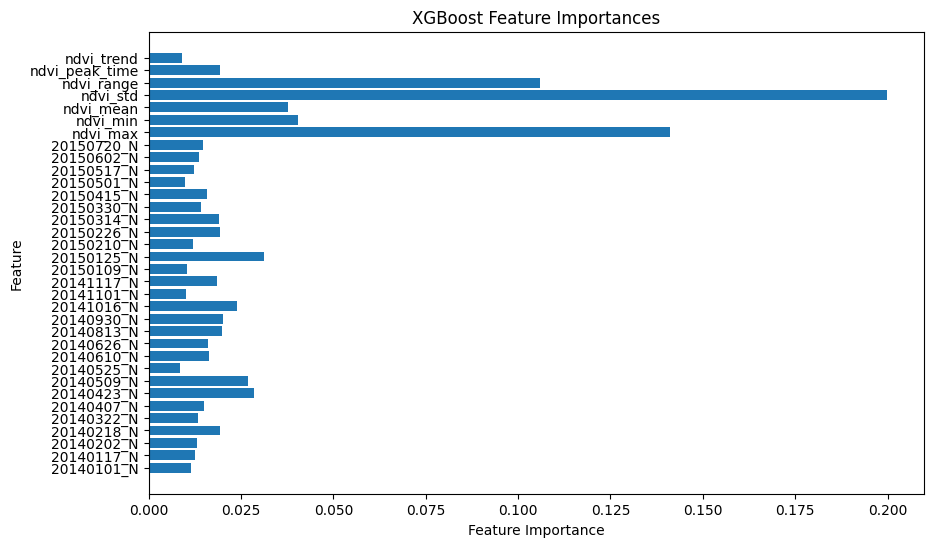

In [22]:
# Feature Importance Check: Added this to understand which features matter most
import matplotlib.pyplot as plt 
plt.figure(figsize=(10, 6)) 
plt.barh(X.columns, best_model.feature_importances_)
plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("XGBoost Feature Importances")
plt.show()

In [23]:
# Error Analysis: Examines where your model makes mistakes
from sklearn.metrics import confusion_matrix 
y_pred = best_model.predict(X) 
print("Confusion Matrix:")
print(confusion_matrix(y_enc, y_pred)) 

Confusion Matrix:
[[ 841    0    0    0    0    0]
 [   0 6159    0    0    0    0]
 [   0    0  196    0    0    0]
 [   0    0    0  669    0    0]
 [   0    0    0    0   30    0]
 [   0    0    0    0    0  105]]
